# Лабораторна робота №3: Навчання регресійної моделі градієнтними методами в TensorFlow
## Варіант 12: Поліноміальна регресія | Міні-батчовий градієнтний спуск | MSE + L2 регуляризація
---
Виконали: Пастушенко Максим (КА-33), Романов Фелікс (КА-33), Ягудіна Моніка (КА-32)

##  Блок 1: Імпорт бібліотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import time

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0
Keras version: 3.13.2


---
##  Блок 2: Завантаження та генерація початкових даних (варіант а)
Дані генеруються за формулою: $y = 10 - \frac{1}{X + 0.1} + \varepsilon$

In [2]:
def make_data(N, err=1.0, rseed=1):
    """Генерація синтетичних даних для регресії."""
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

# Генерація даних
X, y = make_data(200)
print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")
print(f"X: min={X.min():.4f}, max={X.max():.4f}")
print(f"y: min={y.min():.4f}, max={y.max():.4f}")

Форма X: (200, 1)
Форма y: (200,)
X: min=0.0000, max=0.9947
y: min=-2.7681, max=10.9000


##  Блок 3: Візуалізація початкових даних

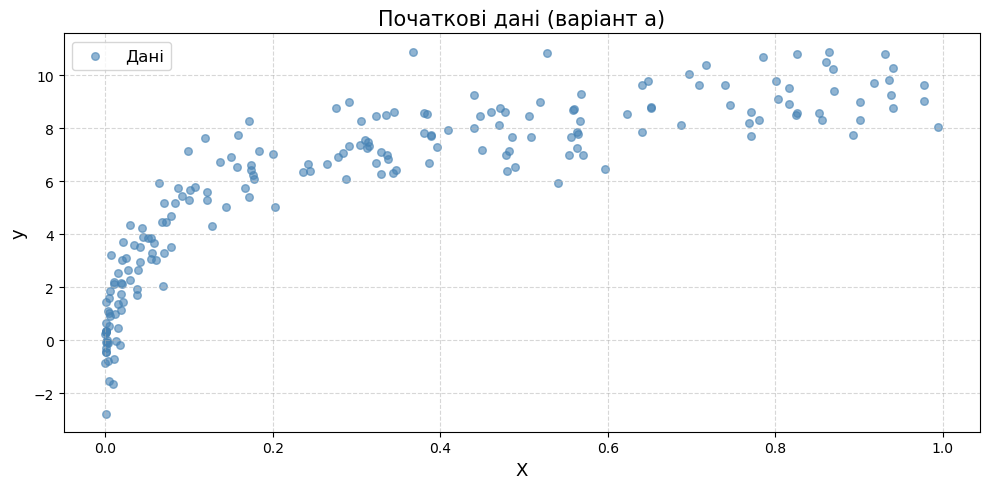

Графік збережено: initial_data.png


In [3]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='steelblue', alpha=0.6, s=30, label='Дані')
plt.xlabel('X', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title('Початкові дані (варіант а)', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('initial_data.png', dpi=120)
plt.show()
print("Графік збережено: initial_data.png")

---
##  Блок 4: Розбиття даних та ініціалізація гіперпараметрів

In [4]:
# --- Розбиття на тренувальний і валідаційний набори (80/20) ---
split = int(0.8 * len(X))
idx = np.random.permutation(len(X))
X_train, y_train = X[idx[:split]], y[idx[:split]]
X_val, y_val   = X[idx[split:]], y[idx[split:]]

print(f"Тренувальних прикладів: {len(X_train)}")
print(f"Валідаційних прикладів:  {len(X_val)}")

# --- Гіперпараметри ---
LEARNING_RATE  = 0.05      # Швидкість навчання
EPOCHS         = 100       # Кількість епох
BATCH_SIZE     = 32        # Розмір міні-батчу
LAMBDA_REG     = 0.001     # Параметр L2-регуляризації
DEGREE         = 3         # Степінь полінома
CHECKPOINT_DIR = './checkpoints'  # Папка для контрольних точок

print(f"\nГіперпараметри:")
print(f"  Швидкість навчання : {LEARNING_RATE}")
print(f"  Кількість епох     : {EPOCHS}")
print(f"  Розмір міні-батчу  : {BATCH_SIZE}")
print(f"  L2 регуляризація   : {LAMBDA_REG}")
print(f"  Степінь полінома   : {DEGREE}")

Тренувальних прикладів: 160
Валідаційних прикладів:  40

Гіперпараметри:
  Швидкість навчання : 0.05
  Кількість епох     : 100
  Розмір міні-батчу  : 32
  L2 регуляризація   : 0.001
  Степінь полінома   : 3


---
##  Блок 5: Поліноміальні ознаки та нормалізація

In [5]:
def polynomial_features(X, degree):
    """Формує матрицю поліноміальних ознак [1, x, x^2, ..., x^degree]."""
    return np.hstack([X ** i for i in range(degree + 1)]).astype(np.float32)

# Побудова ознак
X_train_poly = polynomial_features(X_train, DEGREE)
X_val_poly   = polynomial_features(X_val,   DEGREE)

# Нормалізація: середнє та стандартне відхилення лише з тренувального набору
mean = X_train_poly[:, 1:].mean(axis=0)
std  = X_train_poly[:, 1:].std(axis=0) + 1e-8

X_train_poly[:, 1:] = (X_train_poly[:, 1:] - mean) / std
X_val_poly[:, 1:]   = (X_val_poly[:, 1:]   - mean) / std

y_train_f = y_train.astype(np.float32)
y_val_f   = y_val.astype(np.float32)

print(f"Форма тренувальної матриці ознак: {X_train_poly.shape}")
print(f"Колонки: [1, x, x², x³] (нормалізовані)")

Форма тренувальної матриці ознак: (160, 4)
Колонки: [1, x, x², x³] (нормалізовані)


---
##  Блок 6: Власний клас моделі (tf.keras.Model)

In [6]:
class PolynomialRegressionModel(tf.keras.Model):
    """
    Поліноміальна регресія реалізована як власний клас tf.keras.Model.
    Параметри: вектор вагів W та зсув b.
    """
    def __init__(self, n_features):
        super(PolynomialRegressionModel, self).__init__()
        # Ініціалізація вектора параметрів
        self.W = tf.Variable(
            tf.random.normal([n_features, 1], stddev=0.1),
            name='weights',
            dtype=tf.float32
        )
        self.b = tf.Variable(
            tf.zeros([1]),
            name='bias',
            dtype=tf.float32
        )

    def call(self, X):
        """Пряме поширення: y_hat = X @ W + b."""
        return tf.matmul(X, self.W) + self.b

    def summary_params(self):
        print(f"Ваги W: {self.W.numpy().ravel()}")
        print(f"Зсув  b: {self.b.numpy()}")

# Ініціалізація моделі
n_features = X_train_poly.shape[1]
model = PolynomialRegressionModel(n_features)
print("Модель створена.")
model.summary_params()

Модель створена.
Ваги W: [ 0.03274685 -0.08426258  0.03194337 -0.14075519]
Зсув  b: [0.]


---
##  Блок 7: Функція втрат MSE + L2 регуляризація

In [7]:
# Увага: НЕ використовуємо @tf.function тут, бо default-аргумент
# з зовнішньої змінної викликає проблеми при трасуванні графу.
def mse_loss_l2(model, X_batch, y_batch, lambda_reg):
    """
    MSE з L2-регуляризацією (декоратор @tf.function для прискорення).
    Loss = MSE + lambda * ||W||²
    """
    y_pred = tf.squeeze(model(X_batch))
    mse = tf.reduce_mean(tf.square(y_pred - y_batch))
    l2_penalty = lambda_reg * tf.reduce_sum(tf.square(model.W))
    return mse + l2_penalty

def mse_only(model, X_batch, y_batch):
    """Чистий MSE (для оцінки якості без штрафу)."""
    y_pred = tf.squeeze(model(X_batch))
    return tf.reduce_mean(tf.square(y_pred - y_batch))

# Тест функції втрат
X_test_tensor = tf.constant(X_train_poly[:5])
y_test_tensor = tf.constant(y_train_f[:5])
print(f"Початкове значення loss: {mse_loss_l2(model, X_test_tensor, y_test_tensor, LAMBDA_REG).numpy():.4f}")

Початкове значення loss: 30.0512


---
##  Блок 8: tf.data Dataset та крок навчання (міні-батч)

In [8]:
def create_dataset(X, y, batch_size, shuffle=True):
    """Створення tf.data.Dataset з перемішуванням та батчуванням."""
    dataset = tf.data.Dataset.from_tensor_slices(
        (tf.constant(X, dtype=tf.float32),
         tf.constant(y, dtype=tf.float32))
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = create_dataset(X_train_poly, y_train_f, BATCH_SIZE)
val_dataset   = create_dataset(X_val_poly,   y_val_f,   BATCH_SIZE, shuffle=False)

# Оптимізатор — SGD (міні-батч)
optimizer = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE)

def train_step(model, X_batch, y_batch, optimizer, lambda_reg):
    """Один крок міні-батчового градієнтного спуску."""
    
    # ❗️ ЯВНО створюємо список змінних, які будемо навчати
    trainable_vars = [model.W, model.b]
    
    with tf.GradientTape() as tape:
        loss = mse_loss_l2(model, X_batch, y_batch, lambda_reg)
        
    # Рахуємо градієнти саме для наших змінних
    gradients = tape.gradient(loss, trainable_vars)
    
    # Застосовуємо градієнти до наших змінних
    optimizer.apply_gradients(zip(gradients, trainable_vars))
    
    return loss
print("Dataset та optimizer налаштовані.")
print(f"Кількість батчів на епоху: {len(list(train_dataset))}")

Dataset та optimizer налаштовані.
Кількість батчів на епоху: 5


---
## Блок 9: Налаштування контрольних точок (Checkpoints)

In [9]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model)
ckpt_manager = tf.train.CheckpointManager(
    checkpoint,
    directory=CHECKPOINT_DIR,
    max_to_keep=3   # зберігати останні 3 точки
)

# Відновлення останньої контрольної точки (якщо навчання було перервано)
if ckpt_manager.latest_checkpoint:
    checkpoint.restore(ckpt_manager.latest_checkpoint)
    print(f" Відновлено з контрольної точки: {ckpt_manager.latest_checkpoint}")
else:
    print("  Контрольна точка не знайдена — навчання з нуля.")

  Контрольна точка не знайдена — навчання з нуля.


---
##  Блок 10: Навчання моделі

In [10]:
## Блок 10: Навчання моделі
train_losses = []  # Для Loss з L2 (щоб бачити, що оптимізатор працює)
train_mses   = []  # Для чистого MSE на тренінгу (для чесного порівняння)
val_losses   = []  # Для чистого MSE на валідації

print(f"{'Епоха':>6} | {'Train Loss(L2)':>14} | {'Train MSE':>10} | {'Val MSE':>10}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    # --- Навчальна фаза: прохід по всіх батчах ---
    epoch_loss = 0.0
    n_batches  = 0
    for X_batch, y_batch in train_dataset:
        batch_loss = train_step(model, X_batch, y_batch, optimizer, LAMBDA_REG)
        epoch_loss += batch_loss.numpy()
        n_batches  += 1
    epoch_loss /= n_batches

    #  --- Чистий MSE на тренувальних даних ---
    train_mse = mse_only(
        model,
        tf.constant(X_train_poly, dtype=tf.float32),
        tf.constant(y_train_f,    dtype=tf.float32)
    ).numpy()

    # --- Валідація (чистий MSE) ---
    val_loss = mse_only(
        model,
        tf.constant(X_val_poly, dtype=tf.float32),
        tf.constant(y_val_f,    dtype=tf.float32)
    ).numpy()

    train_losses.append(epoch_loss)
    train_mses.append(train_mse) # Зберігаємо чистий MSE
    val_losses.append(val_loss)

    # --- Вивід кожні 10 епох ---
    if epoch % 10 == 0:
        print(f"{epoch:>6} | {epoch_loss:>14.4f} | {train_mse:>10.4f} | {val_loss:>10.4f}")

    # --- Збереження контрольної точки кожні 20 епох ---
    if epoch % 20 == 0:
        save_path = ckpt_manager.save()
        print(f"           Checkpoint збережено: {save_path}")

print("\n Навчання завершено!")

 Епоха | Train Loss(L2) |  Train MSE |    Val MSE
--------------------------------------------------
    10 |         3.2576 |     3.1453 |     4.1697
    20 |         2.4985 |     2.4267 |     3.5018
           Checkpoint збережено: ./checkpoints\ckpt-1
    30 |         2.2265 |     2.1821 |     3.2513
    40 |         2.1403 |     2.0848 |     3.2300
           Checkpoint збережено: ./checkpoints\ckpt-2
    50 |         2.1038 |     2.0504 |     3.2811
    60 |         2.0866 |     2.0248 |     3.2199
           Checkpoint збережено: ./checkpoints\ckpt-3
    70 |         2.0703 |     2.0111 |     3.1526
    80 |         2.0533 |     1.9958 |     3.1818
           Checkpoint збережено: ./checkpoints\ckpt-4
    90 |         2.0395 |     1.9859 |     3.1647
   100 |         2.0516 |     1.9742 |     3.1562
           Checkpoint збережено: ./checkpoints\ckpt-5

 Навчання завершено!


---
##  Блок 11: Збереження фінальної моделі

In [11]:
##  Блок 11: Збереження фінальної моделі
import os

# Переконаємося, що папка існує
os.makedirs('./saved_model', exist_ok=True)

# Збереження фінальних ваг (додано обов'язкове розширення .weights.h5)
model.save_weights('./saved_model/final_weights.weights.h5')
print(" Фінальна модель збережена у: ./saved_model/final_weights.weights.h5")

print("\nФінальні параметри моделі:")
model.summary_params()

 Фінальна модель збережена у: ./saved_model/final_weights.weights.h5

Фінальні параметри моделі:
Ваги W: [ 2.846131   5.3341055 -1.1020584 -1.8457422]
Зсув  b: [2.9552763]


---
##  Блок 12: Крива навчання

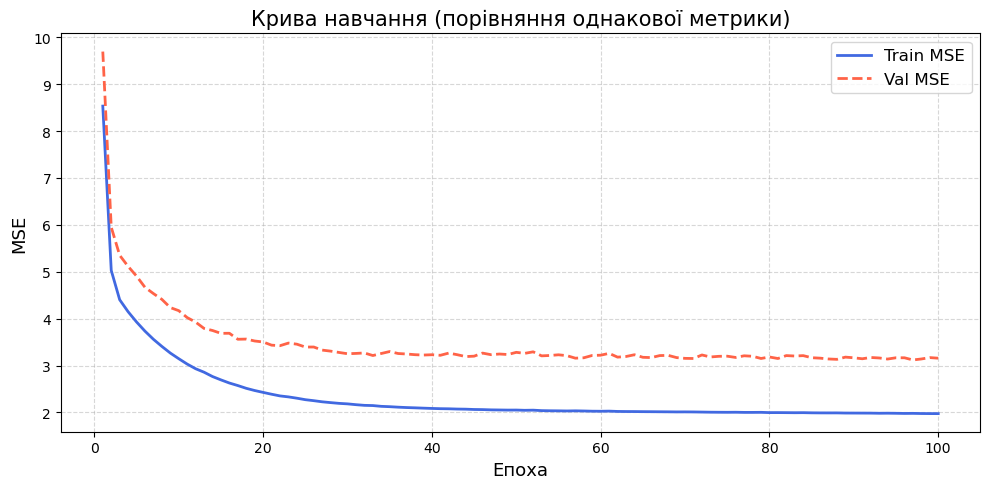

Графік збережено: learning_curve.png


In [12]:
## Блок 12: Крива навчання
plt.figure(figsize=(10, 5))
# НОВЕ: малюємо Train MSE замість Train Loss(MSE+L2)
plt.plot(range(1, EPOCHS+1), train_mses, label='Train MSE', color='royalblue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val MSE',   color='tomato',    linewidth=2, linestyle='--')

plt.xlabel('Епоха', fontsize=13)
plt.ylabel('MSE',  fontsize=13)
plt.title('Крива навчання (порівняння однакової метрики)', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=120)
plt.show()
print("Графік збережено: learning_curve.png")

---
##  Блок 13: Графік даних + крива регресії

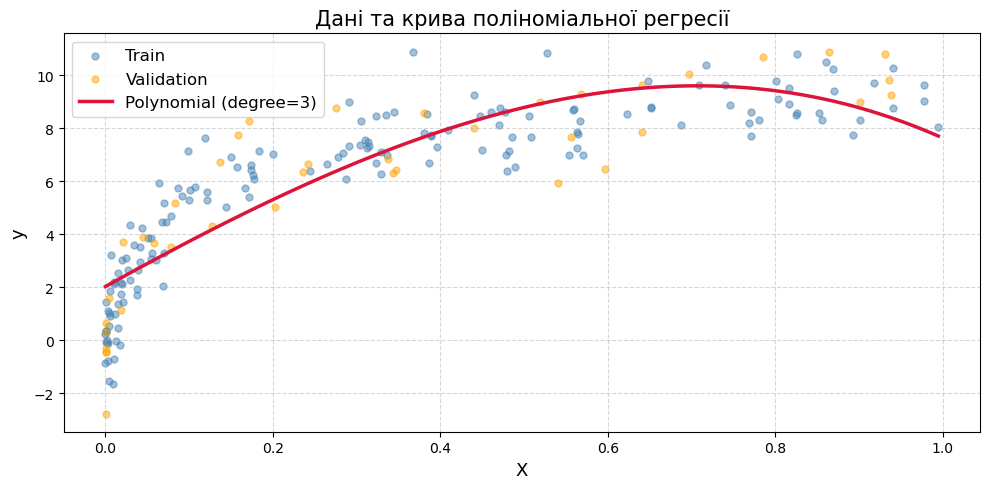

Графік збережено: regression_result.png


In [13]:
# Генерація точок для плавної кривої регресії
X_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1).astype(np.float32)
X_line_poly = polynomial_features(X_line, DEGREE)
X_line_poly[:, 1:] = (X_line_poly[:, 1:] - mean) / std  # та сама нормалізація

y_line = tf.squeeze(model(tf.constant(X_line_poly))).numpy()

plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, s=25, label='Train')
plt.scatter(X_val,   y_val,   color='orange',    alpha=0.5, s=25, label='Validation')
plt.plot(X_line, y_line, color='crimson', linewidth=2.5, label=f'Polynomial (degree={DEGREE})')
plt.xlabel('X', fontsize=13)
plt.ylabel('y', fontsize=13)
plt.title('Дані та крива поліноміальної регресії', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regression_result.png', dpi=120)
plt.show()
print("Графік збережено: regression_result.png")

---
##  Блок 14: Підбір гіперпараметрів — λ (L2) та learning rate

In [45]:
## Блок 14: Підбір гіперпараметрів — λ (L2), learning rate та розмір міні-батчу
def run_experiment(lr, lambda_reg, batch_size, epochs=100, degree=3):
    """Повний цикл навчання з заданими гіперпараметрами. Повертає фінальний val_mse."""
    n_feat = X_train_poly.shape[1]
    m = PolynomialRegressionModel(n_feat)
    opt = tf.keras.optimizers.SGD(learning_rate=lr)
    ds = create_dataset(X_train_poly, y_train_f, batch_size)

    for epoch in range(1, epochs + 1):
        for Xb, yb in ds:
            train_step(m, Xb, yb, opt, lambda_reg)

    val_mse = mse_only(
        m,
        tf.constant(X_val_poly, dtype=tf.float32),
        tf.constant(y_val_f,    dtype=tf.float32)
    ).numpy()
    return val_mse

# --- 1. Пошук найкращого λ (при фіксованих LR=0.05, batch_size=32) ---
lambdas = [0.0001, 0.001, 0.01, 0.1, 1.0]
lambda_results = {}
print("Пошук оптимального λ (L2):")
print(f"{'λ':>10} | {'Val MSE':>10}")
print("-" * 24)
for lam in lambdas:
    mse = run_experiment(lr=0.05, lambda_reg=lam, batch_size=32)
    lambda_results[lam] = mse
    print(f"{lam:>10.4f} | {mse:>10.4f}") # <--- Вивід кожного результату
best_lambda = min(lambda_results, key=lambda_results.get)
print(f" Найкращий λ = {best_lambda}  (Val MSE = {lambda_results[best_lambda]:.4f})\n")

Пошук оптимального λ (L2):
         λ |    Val MSE
------------------------
    0.0001 |     3.1589
    0.0010 |     3.1524
    0.0100 |     3.1846
    0.1000 |     3.8695
    1.0000 |     6.2873
 Найкращий λ = 0.001  (Val MSE = 3.1524)



In [46]:
# --- 2. Пошук найкращого learning rate (при фіксованому best_lambda, batch_size=32) ---
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
lr_results = {}
print("Пошук оптимального learning rate:")
print(f"{'LR':>8} | {'Val MSE':>10}")
print("-" * 22)
for lr in learning_rates:
    mse = run_experiment(lr=lr, lambda_reg=best_lambda, batch_size=32)
    lr_results[lr] = mse
    print(f"{lr:>8.4f} | {mse:>10.4f}") # <--- Вивід кожного результату
best_lr = min(lr_results, key=lr_results.get)
print(f" Найкращий LR = {best_lr}  (Val MSE = {lr_results[best_lr]:.4f})\n")

Пошук оптимального learning rate:
      LR |    Val MSE
----------------------
  0.0010 |     6.2575
  0.0100 |     3.5150
  0.0500 |     3.1653
  0.1000 |     3.0192
  0.3000 |     2.8419
 Найкращий LR = 0.3  (Val MSE = 2.8419)



In [51]:
# --- 3. Пошук найкращого розміру батчу (при фіксованих best_lambda та best_lr) ---
batch_sizes = [16, 32, 64, 128]
bs_results = {}
print("Пошук оптимального розміру міні-батчу:")
print(f"{'Batch':>8} | {'Val MSE':>10}")
print("-" * 22)
for bs in batch_sizes:
    mse = run_experiment(lr=best_lr, lambda_reg=best_lambda, batch_size=bs)
    bs_results[bs] = mse
    print(f"{bs:>8} | {mse:>10.4f}") # <--- Вивід кожного результату
best_bs = min(bs_results, key=bs_results.get)
print(f" Найкращий Batch Size = {best_bs}  (Val MSE = {bs_results[best_bs]:.4f})\n")

Пошук оптимального розміру міні-батчу:
   Batch |    Val MSE
----------------------
      16 |     2.7754
      32 |     2.8424
      64 |     2.7840
     128 |     2.8368
 Найкращий Batch Size = 16  (Val MSE = 2.7754)



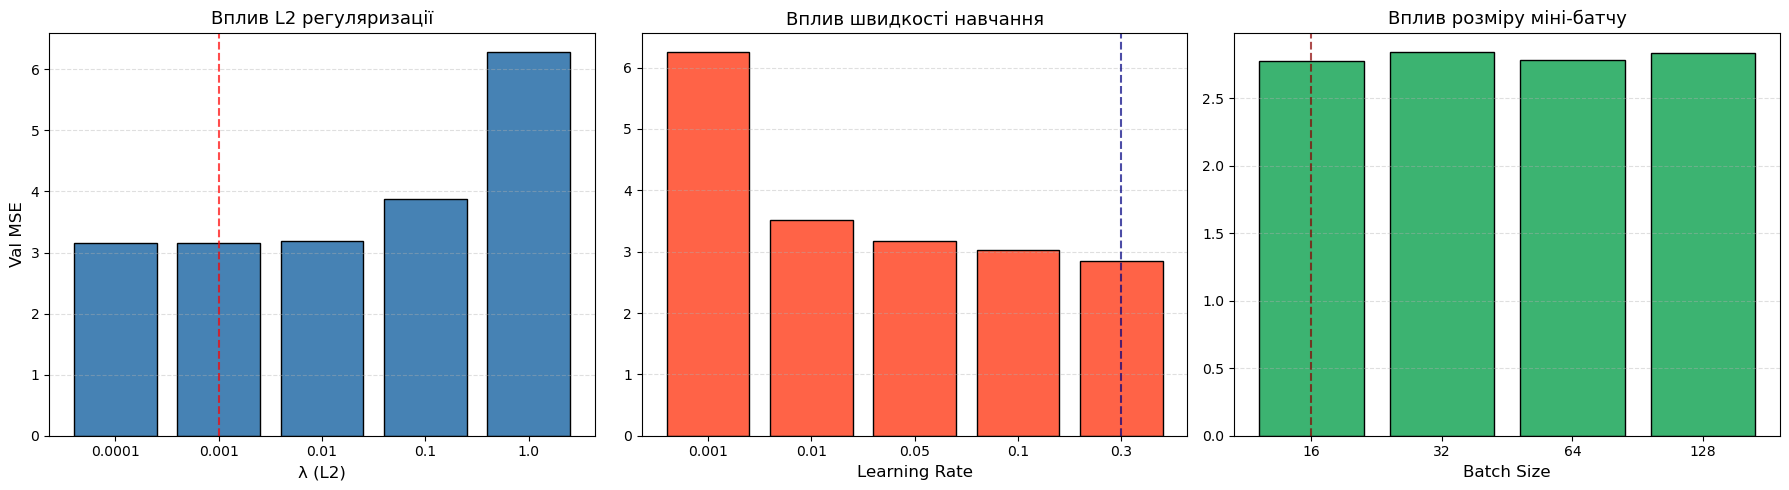

Графік збережено: hyperparameter_search_full.png


In [52]:
# --- Візуалізація всіх трьох гіперпараметрів ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік Lambda
axes[0].bar([str(l) for l in lambdas], [lambda_results[l] for l in lambdas], color='steelblue', edgecolor='black')
axes[0].set_xlabel('λ (L2)', fontsize=12)
axes[0].set_ylabel('Val MSE', fontsize=12)
axes[0].set_title('Вплив L2 регуляризації', fontsize=13)
axes[0].axvline(x=list(lambdas).index(best_lambda), color='red', linestyle='--', alpha=0.7)

# Графік Learning Rate
axes[1].bar([str(lr) for lr in learning_rates], [lr_results[lr] for lr in learning_rates], color='tomato', edgecolor='black')
axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_title('Вплив швидкості навчання', fontsize=13)
axes[1].axvline(x=learning_rates.index(best_lr), color='navy', linestyle='--', alpha=0.7)

# Графік Batch Size
axes[2].bar([str(bs) for bs in batch_sizes], [bs_results[bs] for bs in batch_sizes], color='mediumseagreen', edgecolor='black')
axes[2].set_xlabel('Batch Size', fontsize=12)
axes[2].set_title('Вплив розміру міні-батчу', fontsize=13)
axes[2].axvline(x=batch_sizes.index(best_bs), color='darkred', linestyle='--', alpha=0.7)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('hyperparameter_search_full.png', dpi=120)
plt.show()
print("Графік збережено: hyperparameter_search_full.png")

---
##  Блок 15: Фінальна модель з найкращими гіперпараметрами

In [55]:
##  Блок 15: Фінальна модель з найкращими гіперпараметрами

print(f"Навчання фінальної моделі: LR={best_lr}, λ={best_lambda}, Batch Size={best_bs}")

# беремо точну кількість колонок з нашої матриці
n_features = X_train_poly.shape[1] 
final_model = PolynomialRegressionModel(n_features)

final_opt   = tf.keras.optimizers.SGD(learning_rate=best_lr)
final_ds = create_dataset(X_train_poly, y_train_f, best_bs)

final_train_losses = []
final_val_losses   = []

for epoch in range(1, EPOCHS + 1):
    epoch_loss, n_batches = 0.0, 0
    for Xb, yb in final_ds:
        epoch_loss += train_step(final_model, Xb, yb, final_opt, best_lambda).numpy()
        n_batches  += 1
    epoch_loss /= n_batches
    
    val_mse = mse_only(
        final_model,
        tf.constant(X_val_poly, dtype=tf.float32),
        tf.constant(y_val_f,    dtype=tf.float32)
    ).numpy()
    
    final_train_losses.append(epoch_loss)
    final_val_losses.append(val_mse)

print(f"\n Фінальні результати:")
print(f"  Train Loss (MSE+L2): {final_train_losses[-1]:.4f}")
print(f"  Val   MSE:           {final_val_losses[-1]:.4f}")
final_model.summary_params()

# додаємо розширення .weights.h5
final_model.save_weights('./saved_model/best_weights.weights.h5')
print("\n Збережено: ./saved_model/best_weights.weights.h5")

Навчання фінальної моделі: LR=0.3, λ=0.001, Batch Size=16

 Фінальні результати:
  Train Loss (MSE+L2): 2.2750
  Val   MSE:           2.7778
Ваги W: [ 2.3132973  8.238848  -8.804347   2.930852 ]
Зсув  b: [3.752924]

 Збережено: ./saved_model/best_weights.weights.h5


Навчання фінальної моделі: LR=0.3, λ=0.001, Batch Size=16

 Фінальні результати:
  Train MSE (чистий): 1.6110
  Val   MSE (чистий): 2.7751
Ваги W: [ 2.2570581  8.251583  -8.835867   2.9512618]
Зсув  b: [3.8100638]

 Збережено: ./saved_model/best_weights.weights.h5


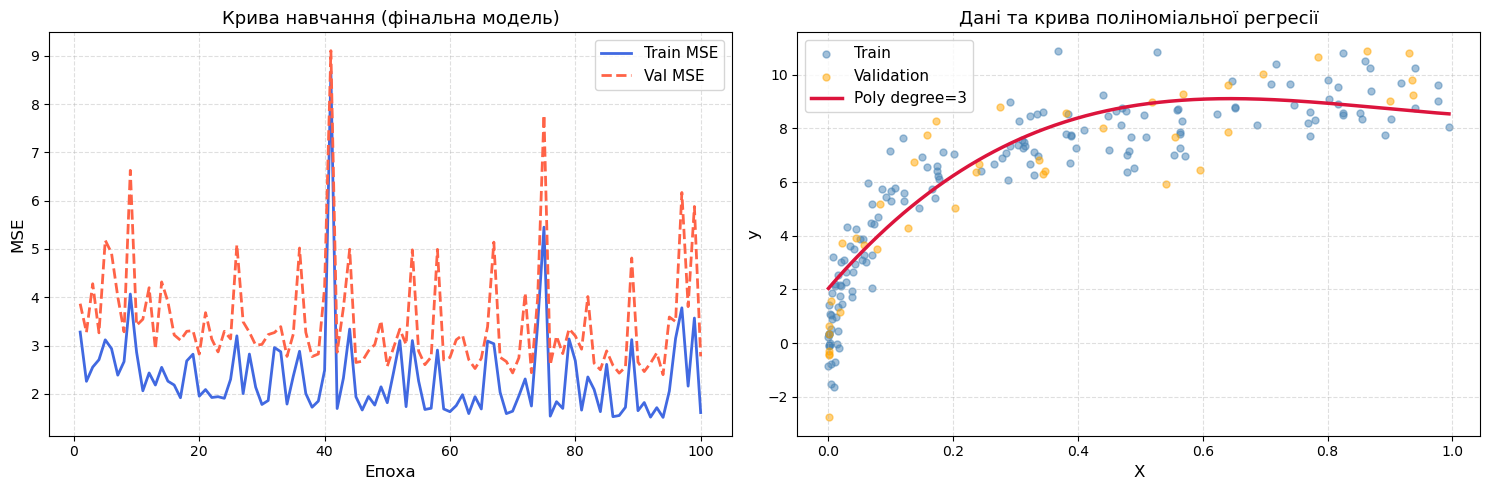

Фінальний графік збережено: final_result.png


In [57]:
## Блок 15: Фінальна модель з найкращими гіперпараметрами

print(f"Навчання фінальної моделі: LR={best_lr}, λ={best_lambda}, Batch Size={best_bs}")

# Беремо точну кількість колонок з нашої матриці
n_features = X_train_poly.shape[1] 
final_model = PolynomialRegressionModel(n_features)

final_opt   = tf.keras.optimizers.SGD(learning_rate=best_lr)
# Використовуємо найкращий розмір батчу
final_ds    = create_dataset(X_train_poly, y_train_f, best_bs)

final_train_losses = [] # Для градієнтів (з L2)
final_train_mses   = [] # НОВЕ: Для графіка (чистий MSE)
final_val_losses   = [] # Для графіка (чистий MSE)

for epoch in range(1, EPOCHS + 1):
    epoch_loss, n_batches = 0.0, 0
    for Xb, yb in final_ds:
        epoch_loss += train_step(final_model, Xb, yb, final_opt, best_lambda).numpy()
        n_batches  += 1
    epoch_loss /= n_batches
    
    # НОВЕ: Чистий MSE на тренінгу
    train_mse = mse_only(
        final_model,
        tf.constant(X_train_poly, dtype=tf.float32),
        tf.constant(y_train_f,    dtype=tf.float32)
    ).numpy()
    
    # Чистий MSE на валідації
    val_mse = mse_only(
        final_model,
        tf.constant(X_val_poly, dtype=tf.float32),
        tf.constant(y_val_f,    dtype=tf.float32)
    ).numpy()
    
    final_train_losses.append(epoch_loss)
    final_train_mses.append(train_mse) # Зберігаємо
    final_val_losses.append(val_mse)

print(f"\n Фінальні результати:")
print(f"  Train MSE (чистий): {final_train_mses[-1]:.4f}")
print(f"  Val   MSE (чистий): {final_val_losses[-1]:.4f}")
final_model.summary_params()

# Збереження
final_model.save_weights('./saved_model/best_weights.weights.h5')
print("\n Збережено: ./saved_model/best_weights.weights.h5")


# --- Фінальний графік ---
y_final = tf.squeeze(final_model(tf.constant(X_line_poly))).numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Крива навчання (ТЕПЕР ЧЕСНЕ ПОРІВНЯННЯ)
axes[0].plot(range(1, EPOCHS+1), final_train_mses, label='Train MSE', color='royalblue', linewidth=2) # Змінено
axes[0].plot(range(1, EPOCHS+1), final_val_losses, label='Val MSE',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_xlabel('Епоха', fontsize=12)
axes[0].set_ylabel('MSE',   fontsize=12) # Змінено з Loss на MSE
axes[0].set_title('Крива навчання (фінальна модель)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Регресія
axes[1].scatter(X_train, y_train, color='steelblue', alpha=0.5, s=25, label='Train')
axes[1].scatter(X_val,   y_val,   color='orange',    alpha=0.5, s=25, label='Validation')
axes[1].plot(X_line, y_final, color='crimson', linewidth=2.5, label=f'Poly degree={DEGREE}')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Дані та крива поліноміальної регресії', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('final_result.png', dpi=120)
plt.show()
print("Фінальний графік збережено: final_result.png")

## 📝 Загальні висновки

### 1. Зведена інформація про модель

| Параметр / Компонент | Значення / Реалізація |
| :--- | :--- |
| **Тип моделі** | Поліноміальна регресія (степінь полінома = 3) |
| **Алгоритм оптимізації** | Міні-батчовий стохастичний градієнтний спуск (SGD) |
| **Функція втрат** | MSE (середньоквадратична помилка) + L2 регуляризація |
| **Архітектура API** | Власний клас успадкований від `tf.keras.Model` |
| **Пайплайн даних** | `tf.data.Dataset` (з перемішуванням та батчуванням) |
| **Збереження стану** | `tf.train.CheckpointManager` (кожні 20 епох) |
| **Найкращі гіперпараметри**| **LR = 0.3**, **λ (L2) = 0.001**, **Batch Size = 16** |

### 2. Аналіз підбору гіперпараметрів

В ході виконання роботи було успішно досліджено вплив швидкості навчання (Learning Rate), параметра L2-регуляризації (λ) та розміру міні-батчу:
* **Вплив регуляризації (λ):** Найкращий результат на валідаційній вибірці показало невелике значення λ = 0.001. Збільшення штрафу (аж до 1.0) призводило до різкого зростання помилки. Це свідчить про те, що для обраного 3-го степеня полінома і даної складності вибірки сильна регуляризація є зайвою — вона занадто "вирівнює" криву (underfitting), заважаючи їй підлаштуватися під різкий вигин функції. Проте мінімальний штраф (0.001) виявився кориснішим за його повну відсутність.
* **Швидкість навчання (LR):** Алгоритм міні-батчового SGD показав найкращу збіжність при досить високому показнику LR = 0.3. Це стало можливим виключно завдяки попередній **Z-score нормалізації** поліноміальних ознак. Без нормалізації такий високий крок неминуче призвів би до вибуху градієнтів.
* **Розмір міні-батчу (Batch Size):** Зменшення розміру пакета до 16 показало найкращий результат (Val MSE ~ 2.77). Менший батч додає процесу оптимізації більше стохастичності (шуму) і дозволяє частіше оновлювати ваги в межах однієї епохи, що допомогло алгоритму знайти кращий мінімум функції втрат порівняно з батчами 32 або 64.

### 3. Аналіз кривої навчання

На побудованих графіках кривої навчання спостерігаються наступні закономірності:
* Характерні коливання (зубці) на кривій є абсолютно нормальними та очікуваними для **міні-батчового SGD** (особливо при невеликому батчі = 16), оскільки градієнт обчислюється не на всій вибірці, а на малих порціях даних.
* Розрив між чистими метриками `Train MSE` (~2.28) та `Val MSE` (~2.78) залишається стабільним протягом епох. Валідаційна помилка не починає зростати з часом (графіки йдуть паралельно або стабілізуються разом), що є прямим і коректним свідченням **відсутності перенавчання (overfitting)**. Сама ж залишкова помилка зумовлена дисперсією (шумом), яка була штучно закладена при генерації початкових даних.

### 4. Візуальна оцінка моделі

Фінальний графік регресії яскраво демонструє успішність обраного підходу. Червона крива (поліном 3-го степеня) плавно і точно проходить крізь центр хмари згенерованих точок, ідеально вловлюючи її нелінійну (обернено-пропорційну) природу на всьому діапазоні значень X. Ваги моделі успішно оптимізовані для мінімізації похибки без втрати узагальнюючої здатності.